# VGG19

Publikacje:
 - https://www.robots.ox.ac.uk/~vgg/publications/2015/Simonyan15/simonyan15.pdf
 - https://www.researchgate.net/publication/346425175_Correlated_Time-Series_in_Multi-Day-Ahead_Streamflow_Forecasting_Using_Convolutional_Networks
 - https://ieeexplore.ieee.org/abstract/document/10551185
 - https://ieeexplore.ieee.org/document/10551185
 - https://ieeexplore.ieee.org/document/11388992
 - https://arxiv.org/abs/1610.02391
 - https://www.researchgate.net/publication/371285678_Interpreting_Hyperspectral_Remote_Sensing_Image_Classification_Methods_via_Explainable_Artificial_Intelligence
 -  transfer learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score
from torch.utils.data import WeightedRandomSampler
# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.image import show_cam_on_image



## Data preparation

(128, 128, 3)
0.22


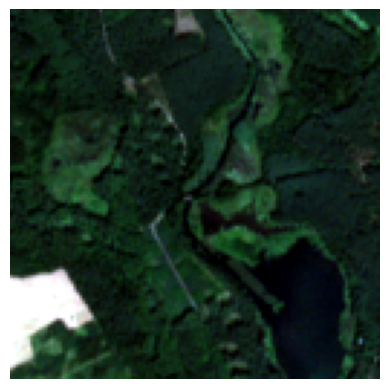

In [2]:
df = pd.read_csv('df_final.csv')
row = df.iloc[1]

chunk_id = int(row["chunk_id"])
chunk = np.load(f"images/images_chunk_{chunk_id:03d}.npy")
image = chunk[int(row['id_in_chunk'])]

rgb_image = image[:, :, 1:4]

rgb_image = rgb_image.astype('float32')
rgb_image = rgb_image / rgb_image.max() if rgb_image.max() > 0 else rgb_image
print(rgb_image.shape)
print(row['flow'])

plt.imshow(rgb_image)
plt.axis('off')
plt.show()

### Split train/test sets

In [3]:
df = pd.read_csv('df_final.csv')
df.head()

,date,flow,chunk_id,id_in_chunk
0,2015-08-10,0.09,0,343
1,2015-08-10,0.22,3,318
2,2015-08-17,0.22,3,317
3,2015-11-25,1.12,1,364
4,2015-08-04,1.43,3,448


In [4]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df = df.sort_values('date').reset_index(drop=True)

train_df = df[df['year'] <= 2022].reset_index(drop=True)
val_df = df[df['year'] == 2023].reset_index(drop=True)
test_df = df[df['year'] == 2024].reset_index(drop=True)

print('Train:', len(train_df))
print('Val:', len(val_df))
print('Test:', len(test_df))

Train: 36993
Val: 7191
Test: 7328


TO DO: split data based on station_id (train based on one group of stations, tets on the other one)

In [5]:
chunk = np.load('images/images_chunk_000.npy')

print(chunk.shape)
print(chunk.dtype)
print(chunk.min(), chunk.max())

(500, 128, 128, 4)
float32
0.0 1.0


### Transform data


In [6]:
def compute_statistics(df, images_num):

    sample = df.sample(min(images_num, len(df)), random_state=42)
    chunk_cache = {}
    rgb_pixel_values = []

    for _, row in sample.iterrows():
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        if chunk_id not in chunk_cache:
            chunk_cache[chunk_id] = np.load(f'images/images_chunk_{chunk_id:03d}.npy',
            mmap_mode = 'r')

        image = chunk_cache[chunk_id][id_in_chunk]
        rgb_image = image[:, :, 1:4].astype('float32')

        p2  = np.percentile(rgb_image, 2)
        p98 = np.percentile(rgb_image, 98)
        rgb_image = np.clip(rgb_image, p2, p98)
        img = (rgb_image - p2) / (p98 - p2 + 1e-8)

        rgb_pixel_values.append(img.reshape(-1, 3))

    pixels = np.concatenate(rgb_pixel_values, axis=0)
    mean   = pixels.mean(axis=0).tolist()
    std    = pixels.std(axis=0).tolist()
    print(f'Mean = {mean}')
    print(f'std  = {std}')
    return mean, std

MEAN, STD = compute_statistics(train_df, 5000)

Mean = [0.20479999482631683, 0.20479999482631683, 0.20479999482631683]
std  = [0.24108798801898956, 0.25323355197906494, 0.23162099719047546]


In [7]:
# MEAN = [0.485, 0.456, 0.406] # Data ImageNet
# STD  = [0.229, 0.224, 0.225]

vgg19_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(
        mean=MEAN,
        std=STD
    )
])

In [8]:
def transform_images(image):
    rgb_image = image[:, :, 1:4]
    rgb_image = rgb_image.astype('float32')
     
    p2  = np.percentile(rgb_image, 2)
    p98 = np.percentile(rgb_image, 98)
    rgb_image = np.clip(rgb_image, p2, p98)
    rgb_image = (rgb_image - p2) / (p98 - p2 + 1e-8) 
    
    x = np.transpose(rgb_image, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32)
    x = vgg19_transform(x)
    return x

In [9]:
row = df.iloc[0]
chunk_id = int(row['chunk_id'])
id_in_chunk = int(row['id_in_chunk'])
    
chunk = np.load(f'images/images_chunk_{chunk_id:03d}.npy')
x = transform_images(chunk[0])
print(x.shape)

torch.Size([3, 224, 224])


/home/epaw0/miniconda3/envs/rsmamba/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


In [10]:
class RiverFlowDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self._chunk_cache = {}
    
    def __len__(self):
        return len(self.df)
    
    def load_chunk(self, chunk_id):
        if chunk_id not in self._chunk_cache:
            self._chunk_cache[chunk_id] = np.load(
                f'images/images_chunk_{chunk_id:03d}.npy',
                mmap_mode='r'
            )
        return self._chunk_cache[chunk_id]

    def __getitem__(self, idx):
        df_row = self.df.iloc[idx]
        chunk_id = int(df_row['chunk_id'])
        id_in_chunk = int(df_row['id_in_chunk'])

        chunk = self.load_chunk(chunk_id)
        image = chunk[id_in_chunk]

        x = transform_images(image)
        y = torch.tensor(np.log1p(df_row['flow']), dtype=torch.float32)
        return x, y
    

In [11]:
train_df.describe()
train_df['flow'].median()

2.32

In [12]:
bins = [0, 50, 200, 500, 10000]
# bins = [0, 2, 9, 42, 200, 3281]
labels = pd.cut(train_df['flow'], bins=bins, labels=False, include_lowest=True)
print(labels.value_counts().sort_index())

class_counts = labels.value_counts()
weights = labels.map(lambda x: 1.0 / np.sqrt(class_counts[x]))
weights = torch.tensor(weights.values, dtype=torch.float)

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


flow
0    33730
1     2046
2      610
3      607
Name: count, dtype: int64


In [13]:
train_loader = DataLoader(RiverFlowDataset(train_df), batch_size=32, sampler=sampler,  num_workers=0)
val_loader   = DataLoader(RiverFlowDataset(val_df),   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(RiverFlowDataset(test_df),  batch_size=32, shuffle=False, num_workers=0)

## Model

In [14]:
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vgg19 = models.vgg19(weights='IMAGENET1K_V1')

True


In [15]:
for param in vgg19.features.parameters(): #zamrozenie
        param.requires_grad = False

vgg19.classifier[6] = nn.Linear(4096, 1)
vgg19.classifier[5].p =0.6
model = vgg19.to(device)

In [16]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4, weight_decay=1e-4)
#, weight_decay=3e-4
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)
num_epochs = 20
losses=[]
val_losses=[]
best_val_loss = float('inf')
patience = 5
epochs_without_improve = 0

In [71]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_id, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        prediction = model(x).squeeze(1)
        loss = criterion(prediction, y)

        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
        if batch_id % 100 == 0:
            print(f"batch {batch_id}/{len(train_loader)}, loss: {loss.item():.4f}")

    train_loss /= len(train_loader.dataset)
    losses.append(train_loss)


    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            val_prediction = model(x).squeeze(1)
            loss = criterion(val_prediction, y)
            val_loss += loss.item() * x.size(0)
        
        val_loss /=len(val_loader.dataset)
        val_losses.append(val_loss)
    scheduler.step(val_loss)
    print(f'Epoch {epoch+1:02d}')
    print(f'Train_loss: {train_loss:.4f}')
    print(f'Val_loss: {val_loss:.4f}')

    if val_loss > best_val_loss:
        epochs_without_improve += 1
        print(f'No improvement - {epochs_without_improve}/{patience}')
        if epochs_without_improve >= patience:
            print('Early stopping.')
            break
    else:
        best_val_loss= val_loss
        epochs_without_improve = 0
        torch.save(model.state_dict(), 'best_model_dropout.pth')

batch 0/1157, loss: 25.0048
batch 100/1157, loss: 0.3093
batch 200/1157, loss: 0.1833
batch 300/1157, loss: 0.3024
batch 400/1157, loss: 0.3850
batch 500/1157, loss: 0.2362
batch 600/1157, loss: 0.2277
batch 700/1157, loss: 0.5467
batch 800/1157, loss: 0.1946
batch 900/1157, loss: 0.2402
batch 1000/1157, loss: 0.3865
batch 1100/1157, loss: 0.2580
Epoch 01
Train_loss: 0.3822
Val_loss: 0.2946
batch 0/1157, loss: 0.2693
batch 100/1157, loss: 0.2400
batch 200/1157, loss: 0.1381
batch 300/1157, loss: 0.3489
batch 400/1157, loss: 0.3549
batch 500/1157, loss: 0.3105
batch 600/1157, loss: 0.2476
batch 700/1157, loss: 0.1798
batch 800/1157, loss: 0.3241
batch 900/1157, loss: 0.1113
batch 1000/1157, loss: 0.3081
batch 1100/1157, loss: 0.2402
Epoch 02
Train_loss: 0.2522
Val_loss: 0.2813
batch 0/1157, loss: 0.3798
batch 100/1157, loss: 0.2756
batch 200/1157, loss: 0.2337
batch 300/1157, loss: 0.1565
batch 400/1157, loss: 0.2433
batch 500/1157, loss: 0.1663
batch 600/1157, loss: 0.1440
batch 700/11

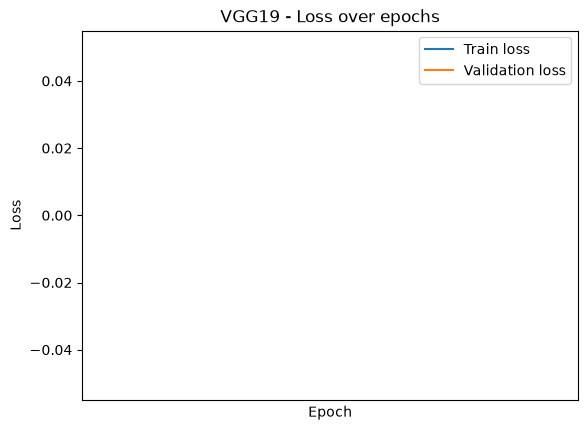

In [19]:
epochs = range(1, len(losses) + 1)
plt.plot(epochs, losses, label='Train loss')
plt.plot(epochs, val_losses, label='Validation loss')

plt.title('VGG19 - Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(list(epochs))
plt.legend()
plt.savefig('best_vgg_dropout.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
model.load_state_dict(torch.load('best_model_dropout.pth', map_location=device))

<All keys matched successfully>

## Evaluation

In [18]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"All parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

All parameters: 139,574,337
Trainable parameters: 119,549,953


In [19]:
for name, param in model.named_parameters():
    print(name, param.numel())
    if param.requires_grad:
        print(name, param.numel())

features.0.weight 1728
features.0.bias 64
features.2.weight 36864
features.2.bias 64
features.5.weight 73728
features.5.bias 128
features.7.weight 147456
features.7.bias 128
features.10.weight 294912
features.10.bias 256
features.12.weight 589824
features.12.bias 256
features.14.weight 589824
features.14.bias 256
features.16.weight 589824
features.16.bias 256
features.19.weight 1179648
features.19.bias 512
features.21.weight 2359296
features.21.bias 512
features.23.weight 2359296
features.23.bias 512
features.25.weight 2359296
features.25.bias 512
features.28.weight 2359296
features.28.bias 512
features.30.weight 2359296
features.30.bias 512
features.32.weight 2359296
features.32.bias 512
features.34.weight 2359296
features.34.bias 512
classifier.0.weight 102760448
classifier.0.weight 102760448
classifier.0.bias 4096
classifier.0.bias 4096
classifier.3.weight 16777216
classifier.3.weight 16777216
classifier.3.bias 4096
classifier.3.bias 4096
classifier.6.weight 4096
classifier.6.weight

In [20]:
model.eval()

pred_y =[]
true_y =[]

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        prediction = model(x).squeeze(1)
        
        pred_y.append(prediction.cpu().numpy())
        true_y.append(y.cpu().numpy())

all_preds =  np.concatenate(pred_y)
all_trues = np.concatenate(true_y)

all_true_y   = np.expm1(all_trues)
all_pred_y = np.expm1(all_preds)
   
mae = mean_absolute_error(all_true_y, all_pred_y)
rmse = np.sqrt(np.mean((all_true_y - all_pred_y) ** 2))
r2 = r2_score(all_true_y, all_pred_y)

flow_range = test_df['flow'].max() - test_df['flow'].min()
mea_percent = 100 * mae / flow_range
rmse_precent = 100 * rmse / flow_range

print('Test dataset')
print(f'MAE: {mea_percent:.2f}% ({mae:.4f})')
print(f'RMSE: {rmse_precent:.2f}% ({rmse:.4f})')
print(f'R2: {r2:.4f}')

/home/epaw0/miniconda3/envs/rsmamba/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


Test dataset
MAE: 0.66% (14.3695)
RMSE: 3.43% (75.1347)
R2: 0.6989


In [21]:
def nse(y_true, y_pred):
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - numerator / denominator

In [22]:
nse_score = nse(all_true_y, all_pred_y)
print(f"NSE: {nse_score:.4f}")

NSE: 0.6989


In [23]:
me = np.mean(all_pred_y - all_true_y)

print("Mean Error:", me)

Mean Error: -7.728357


In [ ]:
model.eval()

pred_y_val =[]
true_y_val =[]

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        prediction = model(x).squeeze(1)
        
        pred_y_val.append(prediction.cpu().numpy())
        true_y_val.append(y.cpu().numpy())

all_preds_val =  np.concatenate(pred_y_val)
all_trues_val = np.concatenate(true_y_val)

all_true_y_val   = np.expm1(all_trues_val)
all_pred_y_val = np.expm1(all_preds_val)
   
mae_val = mean_absolute_error(all_true_y_val, all_pred_y_val)
rmse_val = np.sqrt(np.mean((all_true_y_val - all_pred_y_val) ** 2))
r2_val = r2_score(all_true_y_val, all_pred_y_val)

flow_range_val = val_df['flow'].max() - val_df['flow'].min()
mea_percent = 100 * mae_val/ flow_range_val
rmse_precent = 100 * rmse_val / flow_range_val

print('Validation dataset')
print(f'MAE: {mea_percent:.2f}% ({mae_val:.4f})')
print(f'RMSE: {rmse_precent:.2f}% ({rmse_val:.4f})')
print(f'R2: {r2_val:.4f}')

Validation dataset
MAE: 0.83% (14.7739)
RMSE: 4.44% (79.5635)
R2: 0.7155


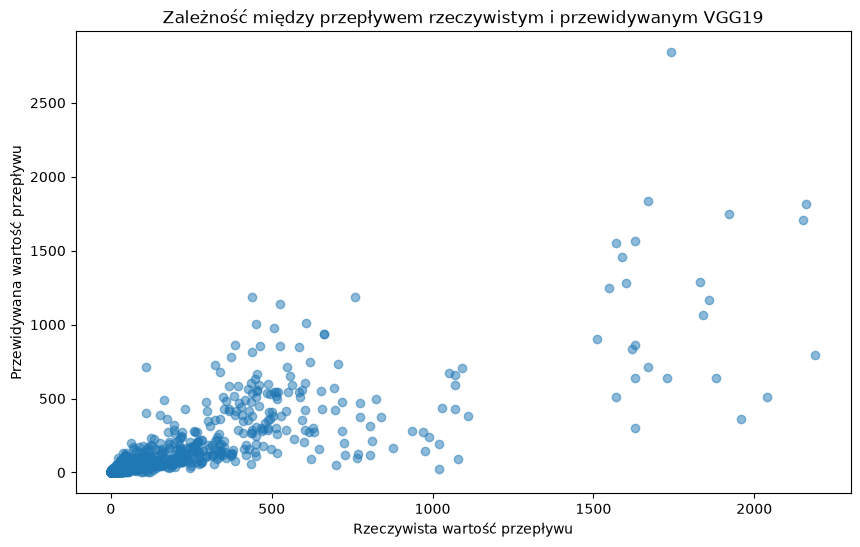

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(all_true_y, all_pred_y, alpha=0.5)
plt.title('Zależność między przepływem rzeczywistym i przewidywanym VGG19')
plt.xlabel('Rzeczywista wartość przepływu')
plt.ylabel('Przewidywana wartość przepływu')
plt.show()

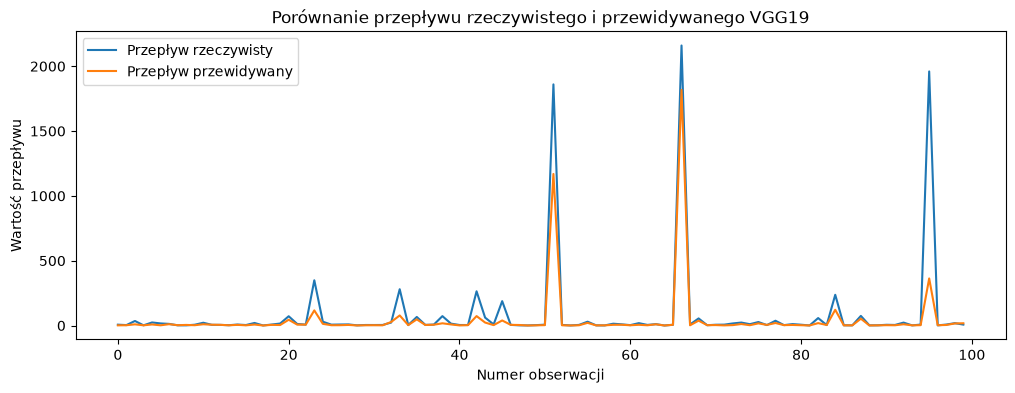

In [25]:
n = 100

plt.figure(figsize=(12, 4))

plt.plot(all_true_y[:n], label='Przepływ rzeczywisty')
plt.plot(all_pred_y[:n], label='Przepływ przewidywany')

plt.xlabel('Numer obserwacji')
plt.ylabel('Wartość przepływu')

plt.title('Porównanie przepływu rzeczywistego i przewidywanego VGG19')

plt.legend()
plt.show()

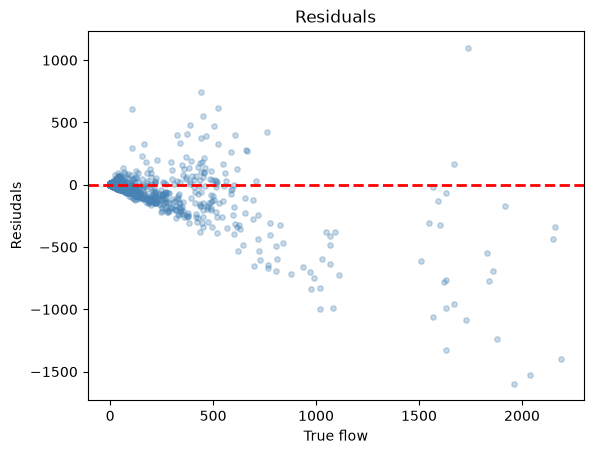

In [26]:
residuals = all_pred_y - all_true_y
plt.scatter(all_true_y, residuals, alpha=0.3, s=15, color='steelblue')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.title('Residuals')
plt.xlabel('True flow')
plt.ylabel('Resiudals')
plt.show()

## Features indetification

- Grad-CAM

Additional:
- Occlusion sensitivity
- Integrated Gradients

In [27]:
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

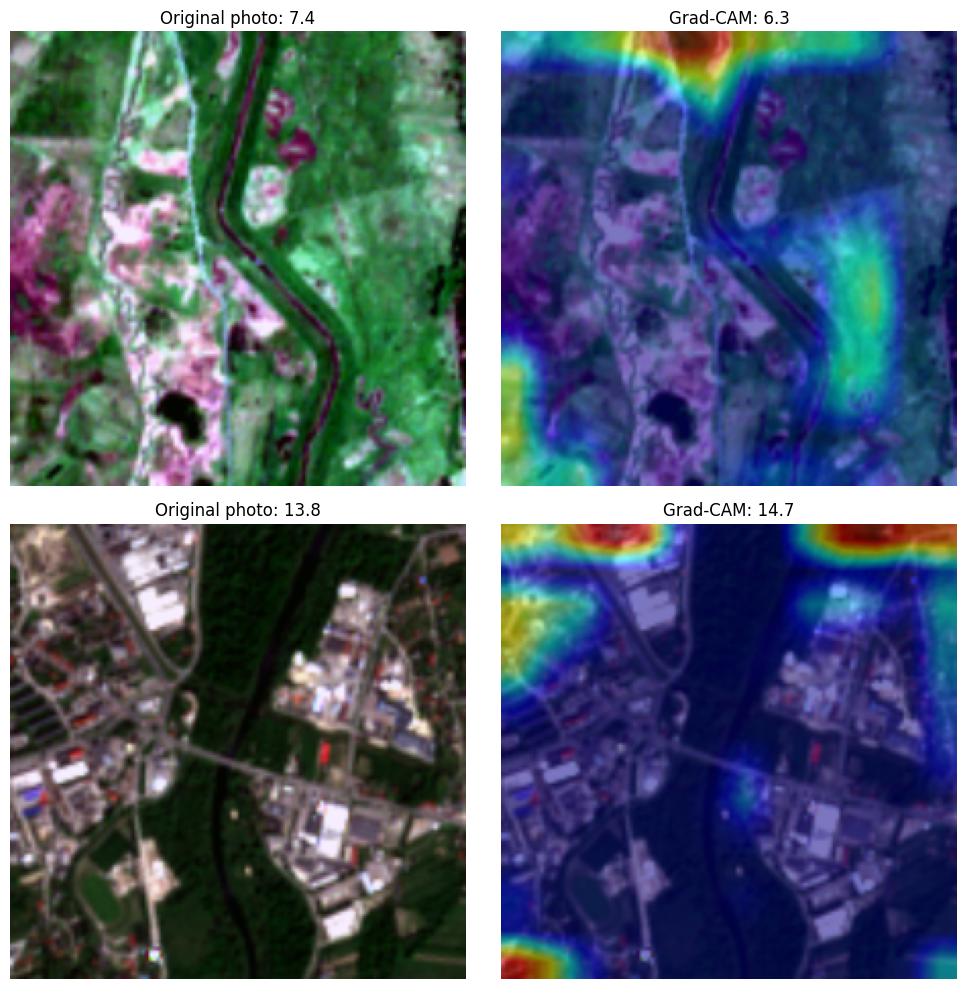

In [ ]:
for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

target_layers = [model.features[34]]
cam = GradCAM(model=model, target_layers=target_layers)
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for i in range(2):
    y = test_df['flow'][i]
    chunk_id = int(test_df['chunk_id'][i])
    chunk = np.load(f"images/images_chunk_{chunk_id:03d}.npy")
    image = chunk[int(test_df['id_in_chunk'][i])]

    x = transform_images(image)
    img_tensor = x.unsqueeze(0).to(device).requires_grad_(True)
    grad_cam = cam(input_tensor=img_tensor)

    img = x.permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = np.float32(img)

    heatmap_on_img = show_cam_on_image(img, grad_cam[0], use_rgb=True)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Original photo: {y:.1f}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(heatmap_on_img)
    axes[i, 1].set_title(f'Grad-CAM: {np.expm1(model(img_tensor).item()):.1f}')
    axes[i, 1].axis('off')
plt.tight_layout()
plt.show()

In [28]:
def occlusion_sensitivity(img_tensor, patch_size=32, stride=16):
    model.eval()

    with torch.no_grad():
        baseline_prediction = model(img_tensor).item()

    _, _, H, W = img_tensor.shape

    heatmap = np.zeros((H, W), dtype=np.float32)
    hidden_counts = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):

            occluded_img = img_tensor.clone()
            occluded_img[:, :, y:y+patch_size, x:x+patch_size] = 0.0

            with torch.no_grad():
                occluded_prediction = model(occluded_img).item()

            difference = difference = abs(baseline_prediction - occluded_prediction)

            heatmap[y:y+patch_size, x:x+patch_size] += difference
            hidden_counts[y:y+patch_size, x:x+patch_size] += 1

    hidden_counts[hidden_counts == 0] = 1
    heatmap = heatmap / hidden_counts

    return heatmap, baseline_prediction

In [29]:
def plot_occlusion(indices, save_path, title):
    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))
    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, id in enumerate(indices):
        row = test_df.iloc[id]
        true_flow = row['flow']
        
        #Pobranie zdjęcia
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        chunk = np.load(f'images/images_chunk_{chunk_id:03d}.npy', mmap_mode='r')
        image = chunk[id_in_chunk]

        x = transform_images(image)
        img_tensor = x.unsqueeze(0).to(device)

        # Heatmap
        heatmap, original_pred = occlusion_sensitivity(img_tensor, 32, 16)
        prediction_flow = np.expm1(original_pred)

        # Normalizacja
        img = x.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.float32(img)

        heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        # Wizualizacja
        axes[row_index, 0].imshow(img)
        axes[row_index, 0].set_title(f'Oryginalny obraz Rzeczywisty: {true_flow:.2f}')
        axes[row_index, 0].axis('off')

        heatmap = axes[row_index, 1].imshow(heatmap_norm, cmap='jet')
        axes[row_index, 1].set_title(f'Mapa istotności  Przewidywany: {prediction_flow:.2f}')
        axes[row_index, 1].axis('off')
        plt.colorbar(
            heatmap,
            ax=axes[row_index, 1],
            fraction=0.04,
            pad=0.04
        )

        axes[row_index, 2].imshow(img)
        axes[row_index, 2].imshow(heatmap_norm, cmap='jet', alpha=0.4)
        axes[row_index, 2].set_title('Mapa istotności nałożona na obraz')
        axes[row_index, 2].axis('off')

    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

In [30]:
def plot_occlusion_combined(indices, flow_labels, save_path, title):

    fig, axes = plt.subplots(len(indices), 3, figsize=(15, 5 * len(indices)))
    if len(indices) == 1:
            axes = np.expand_dims(axes, axis=0)

    for row_index, id in enumerate(indices):
        row = test_df.iloc[id]
        true_flow = row['flow']
        
        #Pobranie zdjęcia
        chunk_id = int(row['chunk_id'])
        id_in_chunk = int(row['id_in_chunk'])
        chunk = np.load(f'images/images_chunk_{chunk_id:03d}.npy', mmap_mode='r')
        image = chunk[id_in_chunk]

        x = transform_images(image)
        img_tensor = x.unsqueeze(0).to(device)
        
        # Heatmap
        heatmap, original_pred = occlusion_sensitivity(img_tensor, 32, 16)
        prediction_flow = np.expm1(original_pred)
        
        # Normalizacja
        img = x.permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.float32(img)
        
        heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
        
             
        # Wizualizacja
        axes[row_index, 0].imshow(img)
        axes[row_index, 0].set_title(f"{flow_labels[row_index]}\n"f"Rzeczywisty przepływ: {true_flow:.2f}")
        axes[row_index, 0].axis('off')
                 
        
        heatmap = axes[row_index, 1].imshow(heatmap_norm, cmap='jet')
        axes[row_index, 1].set_title(f"Mapa istotności\n" f"Predykcja: {prediction_flow:.2f}")        
        axes[row_index, 1].axis('off')
        plt.colorbar(
            heatmap,
            ax=axes[row_index, 1],
            fraction=0.04,
            pad=0.04
        )
        
        axes[row_index, 2].imshow(img)
        axes[row_index, 2].imshow(heatmap_norm, cmap='jet', alpha=0.4)
        axes[row_index, 2].set_title('Mapa istotności nałożona na obraz')
        axes[row_index, 2].axis('off')
        
    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


In [31]:
results_vgg = test_df.copy()
results_vgg["pred_vgg"] = all_pred_y

results_vgg[
    ["chunk_id", "id_in_chunk", "flow", "pred_vgg"]
].to_csv("pred_vgg_2.csv", index=False)

In [38]:
low_index = 4356
medium_index = 5618
high_index = 2654
very_high_index = 462

selected_indices = [
    low_index,
    medium_index,
    high_index,
    very_high_index
]

flow_labels = [
    "Niski przepływ (0-9 m³/s)",
    "Średni przepływ (10-99 m³/s)",
    "Wysoki przepływ (100-499 m³/s)",
    "Bardzo wysoki przepływ (≥500 m³/s)"
]

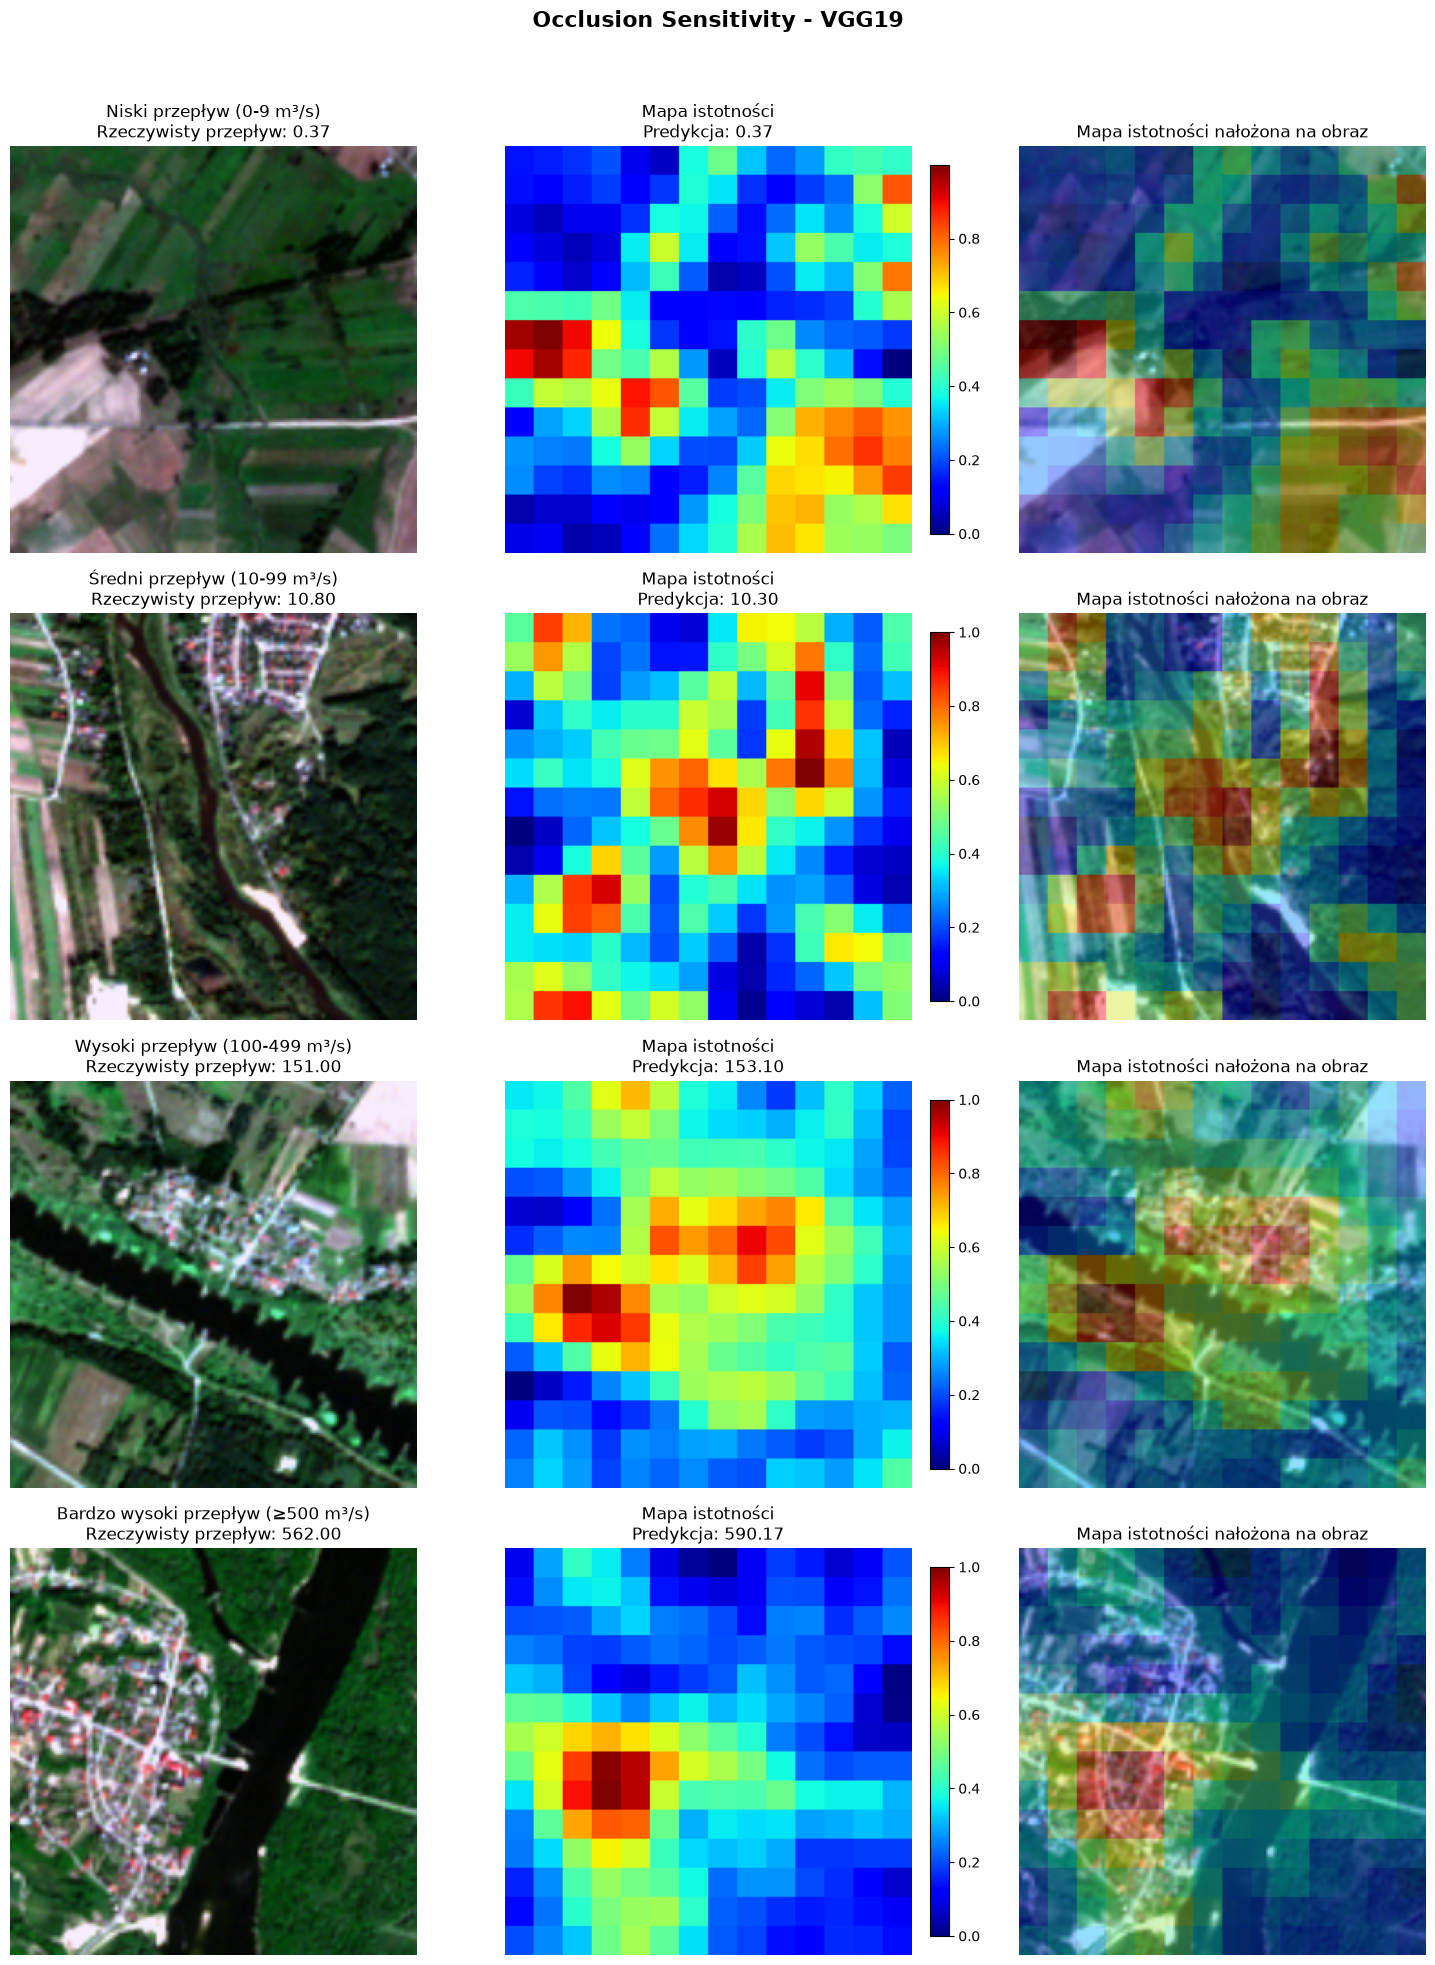

In [39]:
plot_occlusion_combined(
    selected_indices,
    flow_labels,
    title="Occlusion Sensitivity - VGG19",
    save_path="vgg_occlusion_all.png"
)